# ERT (Electrical Resistivity Tomography)

- Emmanuel Castillo & Nadine Ushakov
- emmanuel.castillotaborda@utallas.edu & nadine.igonin@utdallas.edu

# Installation

In [ ]:
!apt-get update
!apt-get install -y \
    build-essential \
    libopenblas-dev \
    libsuitesparse-dev \
    libboost-all-dev \
    cmake \
    python3-dev
!pip uninstall -y \
  numpy numba pytensor jax jaxlib tensorflow spacy pymc librosa \
  dask-cuda umap-learn pynndescent cudf-cu12 stumpy shap \
  tensorflow-decision-forests chex cuml-cu12 dopamine-rl \
  orbax-checkpoint optax flax dask-cudf-cu12 raft-dask-cu12 tsfresh
!pip install --no-deps pgcore==1.5.0
!pip install numpy==1.26.4
!pip install --no-deps pygimli==1.5.4
import os
os._exit(00)

Hit:1 http://archive.ubuntu.com/ubuntu jammy InRelease
Get:2 http://archive.ubuntu.com/ubuntu jammy-updates InRelease [128 kB]
Get:3 http://security.ubuntu.com/ubuntu jammy-security InRelease [129 kB]
Get:4 https://cloud.r-project.org/bin/linux/ubuntu jammy-cran40/ InRelease [3,632 B]
Get:5 https://r2u.stat.illinois.edu/ubuntu jammy InRelease [6,555 B]
Get:6 https://developer.download.nvidia.com/compute/cuda/repos/ubuntu2204/x86_64  InRelease [1,581 B]
Hit:7 https://ppa.launchpadcontent.net/deadsnakes/ppa/ubuntu jammy InRelease
Hit:8 https://ppa.launchpadcontent.net/graphics-drivers/ppa/ubuntu jammy InRelease
Get:9 http://archive.ubuntu.com/ubuntu jammy-backports InRelease [127 kB]
Hit:10 https://ppa.launchpadcontent.net/ubuntugis/ppa/ubuntu jammy InRelease
Get:11 https://r2u.stat.illinois.edu/ubuntu jammy/main all Packages [9,037 kB]
Get:12 https://developer.download.nvidia.com/compute/cuda/repos/ubuntu2204/x86_64  Packages [1,776 kB]
Get:13 http://security.ubuntu.com/ubuntu jammy-sec

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 502.5/502.5 kB 4.2 MB/s eta 0:00:00


## First test
Be sure to have libcholmod.so.3 or libumfpack.so.5. Otherwise you can create symbolic links as described here: https://github.com/gimli-org/gimli/issues/761#issuecomment-2315873346

In [1]:
import os

# List of required shared libraries with full paths
required_libs = [
    "/usr/lib/x86_64-linux-gnu/libcholmod.so.3",
    "/usr/lib/x86_64-linux-gnu/libumfpack.so.5"
]

for lib in required_libs:
    assert os.path.exists(lib), f"Required library not found: {lib}"

print(f"All required shared libraries are present: {required_libs}")

All required shared libraries are present: ['/usr/lib/x86_64-linux-gnu/libcholmod.so.3', '/usr/lib/x86_64-linux-gnu/libumfpack.so.5']


## Second test

- expected_pygimli_version = "1.5.4"
- expected_numpy_version = "1.26.4"

In [2]:
import pygimli
import numpy

expected_pygimli_version = "1.5.4"
expected_numpy_version = "1.26.4"

print("pyGIMLi version:", pygimli.__version__)
print("numpy version:", numpy.__version__)

assert pygimli.__version__ == expected_pygimli_version, f"Expected pyGIMLi {expected_pygimli_version} but got {pygimli.__version__}"
assert numpy.__version__ == expected_numpy_version, f"Expected numpy {expected_numpy_version} but got {numpy.__version__}"

pyGIMLi version: 1.5.4
numpy version: 1.26.4


...ready to work with pygimli!

# Clone our repository

In [3]:
! git clone https://github.com/ecastillot/FieldCampII_2025.git /content/FieldCampII_2025

Cloning into '/content/FieldCampII_2025'...
remote: Enumerating objects: 352, done.
remote: Counting objects: 100% (113/113), done.
remote: Compressing objects: 100% (34/34), done.
remote: Total 352 (delta 62), reused 104 (delta 54), pack-reused 239 (from 1)
Receiving objects: 100% (352/352), 658.11 MiB | 19.45 MiB/s, done.
Resolving deltas: 100% (105/105), done.
Updating files: 100% (253/253), done.


In [5]:
import sys
lib = "/content/FieldCampII_2025"
sys.path.append(lib)

# Download the data from the cloud

In [6]:
!wget -O anwr1_06122025.zip "https://www.dropbox.com/scl/fo/5j2n4xn1gwaa2g906ixif/AGomfMFtHXSGmY8L1n3ZgJI?rlkey=34thzi4108fl429qtr8ftqo2c&dl=1"
!unzip anwr1_06122025.zip -d anwr1_06122025

--2025-06-16 16:05:38--  https://www.dropbox.com/scl/fo/5j2n4xn1gwaa2g906ixif/AGomfMFtHXSGmY8L1n3ZgJI?rlkey=34thzi4108fl429qtr8ftqo2c&dl=1
Resolving www.dropbox.com (www.dropbox.com)... 162.125.4.18, 2620:100:601c:18::a27d:612
Connecting to www.dropbox.com (www.dropbox.com)|162.125.4.18|:443... connected.
HTTP request sent, awaiting response... 302 Found
Location: https://uc4e92a42b2a628621d359d419a8.dl.dropboxusercontent.com/zip_download_get/CPKwTz1ow2gkFLoj8VrH4LbvvH1iM_ifAFofNSkz2N84aEWwPfZQkCOeR9xxcjuFNuUdgaGY64Ae_wLRUIVrbVippUpF-iKQYMq5IAkEgXz6lA# [following]
--2025-06-16 16:05:39--  https://uc4e92a42b2a628621d359d419a8.dl.dropboxusercontent.com/zip_download_get/CPKwTz1ow2gkFLoj8VrH4LbvvH1iM_ifAFofNSkz2N84aEWwPfZQkCOeR9xxcjuFNuUdgaGY64Ae_wLRUIVrbVippUpF-iKQYMq5IAkEgXz6lA
Resolving uc4e92a42b2a628621d359d419a8.dl.dropboxusercontent.com (uc4e92a42b2a628621d359d419a8.dl.dropboxusercontent.com)... 162.125.4.15, 2620:100:601c:15::a27d:60f
Connecting to uc4e92a42b2a628621d359d419a8.dl.d

In [7]:
print("Data folder:",os.path.abspath("anwr1_06122025"))
print("Data downloaded:", os.listdir("anwr1_06122025"))

Data folder: /content/anwr1_06122025
Data downloaded: ['ANWR1.stg', 'ANWR1.cmd', 'ANWR1.zip', 'untitled folder', 'ANWR1.crs']


 # Reading the data

We created some useful functions to upload the data for you. You can use them only importing fc2 library (field camp 2)

In [8]:
from fc2 import ert as fc2_ert # this is a library we built for you to us
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

## STG Data

The file with **format .stg** is created by SuperString, and it contains the result of a resistivity measurement. Check **Section 7** in the manual here:

 https://github.com/ecastillot/FieldCampII_2025/blob/main/data/ROC_ERT_032625/AGI-SuperStingManual.pdf

 We created a function to read the file for you

In [9]:
print(help(fc2_ert.parse_stg))

Help on function parse_stg in module fc2.ert:

parse_stg(filepath, join_date_time=True)
    Read a .stg file exported from SuperSting and return a pandas DataFrame.
    
    Parameters:
        filepath (str): Path to the .stg file.
        join_date_time (bool): If True, combine date and time into a single datetime object in 'date_time' column.
    
    Returns:
        pd.DataFrame: Parsed .stg data.

None


In [48]:
# change this path to load your own data
#stg_filepath = "/content/FieldCampII_2025/data/ROC_ERT_032625/ROC2025.stg"
stg_filepath = "/content/anwr1_06122025/ANWR1.stg"

# Load the STG file
stg = fc2_ert.parse_stg(stg_filepath)

# Electrode separation?
electrode_separation = 6
stg['Ax'] = stg['Ax'] * electrode_separation
stg['Bx'] = stg['Bx'] * electrode_separation
stg['Mx'] = stg['Mx'] * electrode_separation
stg['Nx'] = stg['Nx'] * electrode_separation

display(stg.head())
print("Columns:", stg.columns.tolist())
stg.to_csv("stg.csv", index=False) # in case you want to export it

,record_num,user,date_time,V/I,error_percent_tenths,current_mA,resistivity,command_id,Ax,Ay,...,Nz,ip_time_slot_ms,ip_time_constant,ip_slot1,ip_slot2,ip_slot3,ip_slot4,ip_slot5,ip_slot6,ip_total
0,1,USER,2025-06-12 11:09:36,0.511698,19,71,9.64528,ANWR1,6.0,0.0,...,0.0,100,500,0.003174,0.002187,0.002005,0.001306,0.001017,0.000942,0.010631
1,2,USER,2025-06-12 11:09:59,0.173674,36,71,13.09470,ANWR1,6.0,0.0,...,0.0,100,500,0.005367,0.002743,0.001371,0.001968,0.000477,0.000655,0.012581
2,3,USER,2025-06-12 11:10:21,0.091590,44,71,17.26420,ANWR1,6.0,0.0,...,0.0,100,500,0.002867,0.002865,0.001810,0.000149,0.000754,0.003318,0.011763
3,4,USER,2025-06-12 11:10:44,0.082930,55,71,31.26400,ANWR1,6.0,0.0,...,0.0,100,500,0.016027,0.137827,-0.127146,-0.000999,0.009349,-0.000336,0.034722
4,5,USER,2025-06-12 11:11:06,0.035224,54,71,23.23870,ANWR1,6.0,0.0,...,0.0,100,500,0.019200,0.010133,0.008800,0.005867,0.002400,-0.002933,0.043467


Columns: ['record_num', 'user', 'date_time', 'V/I', 'error_percent_tenths', 'current_mA', 'resistivity', 'command_id', 'Ax', 'Ay', 'Az', 'Bx', 'By', 'Bz', 'Mx', 'My', 'Mz', 'Nx', 'Ny', 'Nz', 'ip_time_slot_ms', 'ip_time_constant', 'ip_slot1', 'ip_slot2', 'ip_slot3', 'ip_slot4', 'ip_slot5', 'ip_slot6', 'ip_total']


Review the summary. (Notice the values of Ay, Az,By,Bz,My, Mz)

In [49]:
stg[["current_mA","resistivity","Ax","Ay","Az","Bx","By","Bz","Mx","My","Mz","Nx","Ny","Nz"]].describe()

,current_mA,resistivity,Ax,Ay,Az,Bx,By,Bz,Mx,My,Mz,Nx,Ny,Nz
count,170.000000,170.000000,170.000000,170.0,170.0,170.000000,170.0,170.0,170.000000,170.0,170.0,170.000000,170.0,170.0
mean,103.264706,17.183620,30.564706,0.0,0.0,34.447059,0.0,0.0,53.223529,0.0,0.0,61.764706,0.0,0.0
std,38.044126,95.717890,18.173683,0.0,0.0,26.241259,0.0,0.0,18.628969,0.0,0.0,19.826255,0.0,0.0
min,14.000000,-666.607000,0.000000,0.0,0.0,0.000000,0.0,0.0,6.000000,0.0,0.0,12.000000,0.0,0.0
25%,77.750000,1.363365,18.000000,0.0,0.0,12.000000,0.0,0.0,42.000000,0.0,0.0,48.000000,0.0,0.0
50%,97.000000,9.019390,30.000000,0.0,0.0,30.000000,0.0,0.0,54.000000,0.0,0.0,66.000000,0.0,0.0
75%,118.250000,18.352025,42.000000,0.0,0.0,54.000000,0.0,0.0,66.000000,0.0,0.0,78.000000,0.0,0.0
max,189.000000,685.256000,78.000000,0.0,0.0,90.000000,0.0,0.0,84.000000,0.0,0.0,90.000000,0.0,0.0


let's check the resistivity. Negative values usually indicate: Instrumental error, bad or noisy data (e.g., poor electrode contact or external interference)

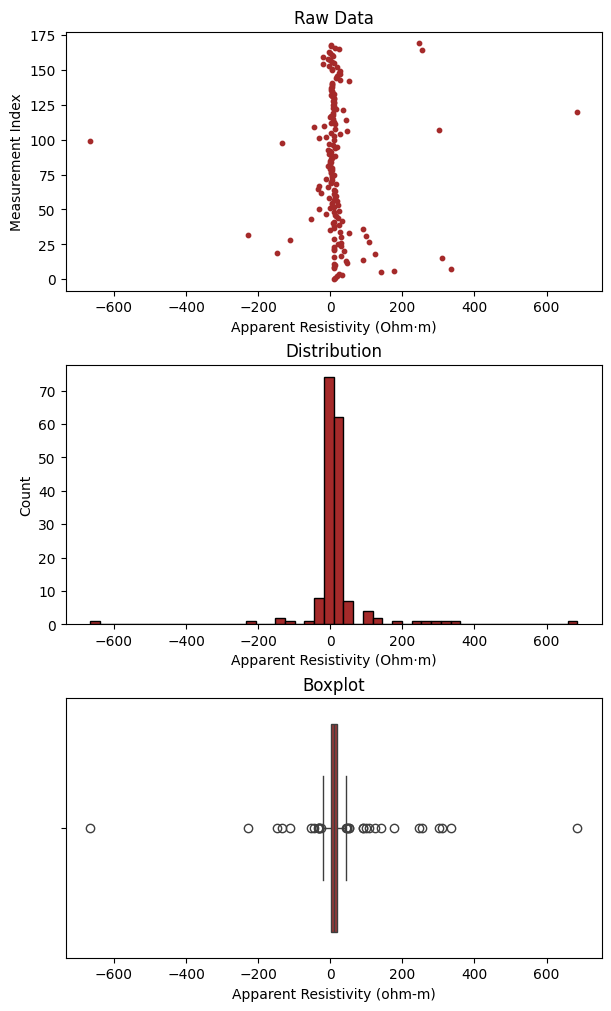

In [50]:
import seaborn as sns
import matplotlib.pyplot as plt

fig, axs = plt.subplots(3, 1, figsize=(6, 10), sharex=True, constrained_layout=True)

# 1st subplot: Scatter plot
axs[0].scatter(stg['resistivity'], stg.index, color='brown', s=10)
axs[0].set_title("Raw Data")
axs[0].set_ylabel("Measurement Index")
axs[0].set_xlabel("Apparent Resistivity (Ohm·m)")

# 2ndsubplot: Histogram
axs[1].hist(stg['resistivity'], bins=50, color='brown', edgecolor='black')
axs[1].set_title("Distribution")
axs[1].set_xlabel("Apparent Resistivity (Ohm·m)")
axs[1].set_ylabel("Count")

# 3rd subplot: Horizontal boxplot with resistivity on x-axis
sns.boxplot(x=stg['resistivity'].dropna(), color='brown', ax=axs[2])
axs[2].set_title("Boxplot")
axs[2].set_xlabel("Apparent Resistivity (ohm-m)")
axs[2].set_ylabel("")

# Force x-axis tick labels visible on all subplots
for ax in axs:
    ax.xaxis.set_tick_params(labelbottom=True)

plt.savefig("stg_resistivity_original.png", dpi=300)
plt.show()

We need to remove nan, negative and outliers values

In [51]:
# Filter the DataFrame for valid resistivity and error values
stg = stg[(stg['resistivity'] > 0) & (np.isfinite(stg['resistivity'])) &
          (stg['error_percent_tenths'] > 0) & (np.isfinite(stg['error_percent_tenths']))]

## Removing outliers
Q1 = stg['resistivity'].quantile(0.25)
Q3 = stg['resistivity'].quantile(0.75)
IQR = Q3 - Q1
# Define bounds
lower_bound = Q1 - 1.5 * IQR
#upper_bound = Q3 + 5 * IQR
upper_bound = 400

# Filter
stg = stg[(stg['resistivity'] >= lower_bound) & (stg['resistivity'] <= upper_bound)]

print("Filtered data")
display(stg.describe())

Filtered data


,record_num,date_time,V/I,error_percent_tenths,current_mA,resistivity,Ax,Ay,Az,Bx,...,Nz,ip_time_slot_ms,ip_time_constant,ip_slot1,ip_slot2,ip_slot3,ip_slot4,ip_slot5,ip_slot6,ip_total
count,137.000000,137,137.000000,137.000000,137.000000,137.000000,137.000000,137.0,137.0,137.000000,...,137.0,137.0,137.0,137.000000,137.000000,137.000000,137.000000,137.000000,137.000000,137.000000
mean,83.854015,2025-06-12 11:38:33.759124224,0.867213,46.240876,102.328467,28.610762,29.518248,0.0,0.0,34.116788,...,0.0,100.0,500.0,-0.005729,-0.003281,-5.992471,5.983927,-0.003859,-0.012618,-0.034032
min,1.000000,2025-06-12 11:09:36,0.001785,8.000000,15.000000,0.174110,0.000000,0.0,0.0,0.000000,...,0.0,100.0,500.0,-0.684504,-0.413774,-819.968000,-0.144837,-0.380952,-0.986961,-2.531540
25%,39.000000,2025-06-12 11:23:22,0.029520,21.000000,74.000000,4.499480,12.000000,0.0,0.0,12.000000,...,0.0,100.0,500.0,-0.000192,-0.001061,-0.000954,-0.001174,0.000130,-0.000264,-0.001420
50%,84.000000,2025-06-12 11:39:25,0.134809,35.000000,97.000000,10.164300,24.000000,0.0,0.0,30.000000,...,0.0,100.0,500.0,0.002290,0.001555,0.001090,0.000680,0.000731,0.000575,0.007103
75%,129.000000,2025-06-12 11:53:39,0.420997,58.000000,116.000000,23.724600,42.000000,0.0,0.0,54.000000,...,0.0,100.0,500.0,0.005209,0.002865,0.002109,0.001360,0.001268,0.000917,0.013506
max,170.000000,2025-06-12 12:07:07,40.568400,363.000000,189.000000,335.167000,78.000000,0.0,0.0,90.000000,...,0.0,100.0,500.0,0.264681,0.195358,0.062043,820.069000,0.032511,0.222359,0.418809
std,50.580969,NaN,4.772416,43.720457,38.954179,57.906570,19.071885,0.0,0.0,25.515585,...,0.0,0.0,0.0,0.091712,0.052360,70.053987,70.063396,0.035639,0.110584,0.287607


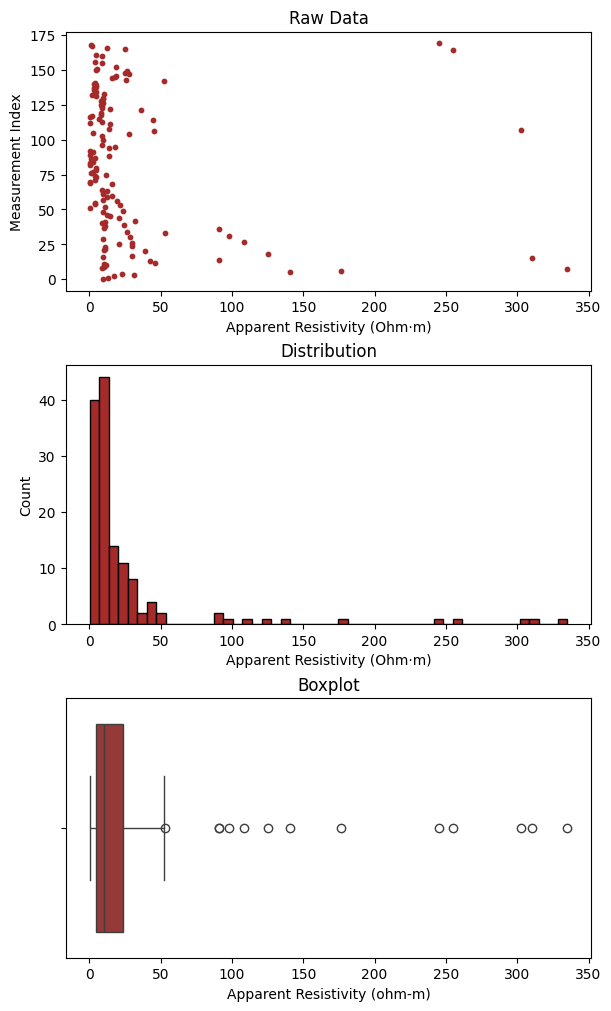

In [52]:
import seaborn as sns
import matplotlib.pyplot as plt

fig, axs = plt.subplots(3, 1, figsize=(6, 10), sharex=True, constrained_layout=True)

# 1st subplot: Scatter plot
axs[0].scatter(stg['resistivity'], stg.index, color='brown', s=10)
axs[0].set_title("Raw Data")
axs[0].set_ylabel("Measurement Index")
axs[0].set_xlabel("Apparent Resistivity (Ohm·m)")

# 2ndsubplot: Histogram
axs[1].hist(stg['resistivity'], bins=50, color='brown', edgecolor='black')
axs[1].set_title("Distribution")
axs[1].set_xlabel("Apparent Resistivity (Ohm·m)")
axs[1].set_ylabel("Count")

# 3rd subplot: Horizontal boxplot with resistivity on x-axis
sns.boxplot(x=stg['resistivity'].dropna(), color='brown', ax=axs[2])
axs[2].set_title("Boxplot")
axs[2].set_xlabel("Apparent Resistivity (ohm-m)")
axs[2].set_ylabel("")

# Force x-axis tick labels visible on all subplots
for ax in axs:
    ax.xaxis.set_tick_params(labelbottom=True)

plt.savefig("stg_resistivity_filtered.png", dpi=300)
plt.show()

There are some other functions like:
- **fc2_ert.parse_cmd** to read CMD format
- **fc2_ert.parse_crs** to read CRS format

# ERT Analysis

In [53]:
import pygimli as pg
import pygimli.meshtools as mt
from pygimli.physics import ert
from pygimli.physics.ert import drawERTData

## Step 1: Geometry of the sensors

Extract unique electrode positions

In [26]:
electrodes = np.unique(np.concatenate([
    stg[['Ax']].values,  # Assuming 2D, use x-coordinates
    stg[['Bx']].values,
    stg[['Mx']].values,
    stg[['Nx']].values
], axis=0)).flatten()  # Ensure a 1D array
print(electrodes)

[ 0.  6. 12. 18. 24. 30. 36. 42. 48. 54. 60. 66. 72. 78. 84. 90.]


Sort electrodes by x-coordinate for a 2D line, and add a new dimension because it expects a 2D array

In [54]:
electrodes = np.sort(electrodes)
sensors = np.column_stack((electrodes, np.zeros_like(electrodes)))  # Add y=0 for 2D

print("Electrodes shape:", electrodes.shape)
print("Electrodes (first few):", electrodes[:5])
print("Min electrode x:", min(electrodes))
print("Max electrode x:", max(electrodes))
print()
print("Sensors shape:", sensors.shape)

Electrodes shape: (16,)
Electrodes (first few): [ 0.  6. 12. 18. 24.]
Min electrode x: 0.0
Max electrode x: 90.0

Sensors shape: (16, 2)


## Part 2: Assign values to the PyGIMLi ERT Data Container

Create a PyGIMLi data container and set sensor (electrode) positions

In [55]:
data = pg.DataContainerERT()
for i, pos in enumerate(sensors):
    data.createSensor(pos)
print(data)

Data: Sensors: 16 data: 0, nonzero entries: ['a', 'b', 'm', 'n']


Extract the A, B, M, N indices and the resistivity data
---



In [56]:
# Map electrode positions to indices
# key: the value in the dataframe. val: the index
electrode_dict = {x: i for i, x in enumerate(electrodes)}

# Convert electrode positions to indices for each electrode type
a = [electrode_dict[x] for x in stg['Ax']]
b = [electrode_dict[x] for x in stg['Bx']]
m = [electrode_dict[x] for x in stg['Mx']]
n = [electrode_dict[x] for x in stg['Nx']]

# Resistivity and error
r = [x for x in stg['resistivity']]
e = [x / 1000.0 for x in stg['error_percent_tenths']]

# Print results with clear formatting
print("\nElectrode Dictionary")
print(electrode_dict)

print("\nFirst 5 A electrode indices:", a[:5])
print("First 5 B electrode indices:", b[:5])
print("First 5 M electrode indices:", m[:5])
print("First 5 N electrode indices:", n[:5])

print("\nFirst 5 Apparent Resistivity values:", r[:5])
print("First 5 Error values (converted to float):", e[:5])


Electrode Dictionary
{0.0: 0, 6.0: 1, 12.0: 2, 18.0: 3, 24.0: 4, 30.0: 5, 36.0: 6, 42.0: 7, 48.0: 8, 54.0: 9, 60.0: 10, 66.0: 11, 72.0: 12, 78.0: 13, 84.0: 14, 90.0: 15}

First 5 A electrode indices: [1, 1, 1, 1, 1]
First 5 B electrode indices: [0, 0, 0, 0, 0]
First 5 M electrode indices: [2, 3, 4, 5, 6]
First 5 N electrode indices: [3, 4, 5, 6, 7]

First 5 Apparent Resistivity values: [9.64528, 13.0947, 17.2642, 31.264, 23.2387]
First 5 Error values (converted to float): [0.019, 0.036, 0.044, 0.055, 0.054]


Set the data and compute the geometric factor

In [57]:
data.resize(len(stg))  # Set number of measurements
data.set('a', a)  # Current electrode A indices
data.set('b', b)  # Current electrode B indices
data.set('m', m)  # Potential electrode M indices
data.set('n', n)  # Potential electrode N indices
data.set('rhoa', r)  # Apparent resistivity
data.set('err', e)  # Error as fraction
data['k'] = pg.physics.ert.createGeometricFactors(data, verbose=True)

# You can save the data for further use
pygimli_dataout = 'ert_pygimli.dat'
data.save(pygimli_dataout)

print()
print("Apparent resistivity values summary:")
print("Min:", np.min(data['rhoa']))
print("Max:", np.max(data['rhoa']))
print("Any positive?", np.any(data['rhoa'] > 0))
print("Any NaNs?", np.any(np.isnan(data['rhoa'])))
print("Any zeros?", np.any(data['rhoa'] == 0))

print()
print(f"Data is saved here: {pygimli_dataout}")

INFO:pyGIMLi:Calculate analytical flat earth geometric factors.
16/06/25 - 16:17:32 - pyGIMLi - INFO - Calculate analytical flat earth geometric factors.
INFO:pyGIMLi:Save RVector binary
16/06/25 - 16:17:32 - pyGIMLi - INFO - Save RVector binary
INFO:pyGIMLi:Cache stored: /root/.cache/pygimli/4577918235709643568
16/06/25 - 16:17:32 - pyGIMLi - INFO - Cache stored: /root/.cache/pygimli/4577918235709643568



Apparent resistivity values summary:
Min: 0.17411
Max: 335.167
Any positive? True
Any NaNs? False
Any zeros? False

Data is saved here: ert_pygimli.dat


## Part 3: Inversion

### Unstructured data

#### Geometry for the inversion

In [58]:
# Create a geometry for the inversion
x_min = np.min(electrodes) - 10  # Extend 10 units beyond min electrode
x_max = np.max(electrodes) + 10  # Extend 10 units beyond max electrode
y_min = -20  # Depth of the model
y_max = 0    # Surface

print(f"World bounds: x_min={x_min}, x_max={x_max}, y_min={y_min}, y_max={y_max}")

World bounds: x_min=-10.0, x_max=100.0, y_min=-20, y_max=0


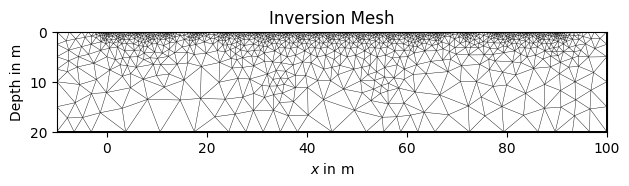

In [61]:
world = mt.createWorld(start=[x_min, y_max], end=[x_max, y_min],
                        worldMarker=True)

# Add electrodes to the geometry for mesh refinement
for p in data.sensors():
    world.createNode(p)
    world.createNode(p - [0, 0.1])  # Refine near electrodes

# Create a mesh for inversion
mesh = mt.createMesh(world, quality=34)

# Take a look at the mesh and the resistivity distribution
pg.show(mesh, showMesh=True)
plt.title("Inversion Mesh")
plt.savefig("unstructured_mesh.png", dpi=300)
plt.show()

#### Inversion

INFO:pyGIMLi:Found 2 regions.
16/06/25 - 16:35:45 - pyGIMLi - INFO - Found 2 regions.
INFO:pyGIMLi:(ERTModelling) Region with smallest marker (1) set to background.
16/06/25 - 16:35:45 - pyGIMLi - INFO - (ERTModelling) Region with smallest marker (1) set to background.
INFO:pyGIMLi:Found 2 regions.
16/06/25 - 16:35:45 - pyGIMLi - INFO - Found 2 regions.
INFO:pyGIMLi:(ERTModelling) Region with smallest marker (1) set to background.
16/06/25 - 16:35:45 - pyGIMLi - INFO - (ERTModelling) Region with smallest marker (1) set to background.
INFO:pyGIMLi:Creating forward mesh from region infos.
16/06/25 - 16:35:45 - pyGIMLi - INFO - Creating forward mesh from region infos.
INFO:pyGIMLi:Creating refined mesh (H2) to solve forward task.
16/06/25 - 16:35:45 - pyGIMLi - INFO - Creating refined mesh (H2) to solve forward task.
INFO:pyGIMLi:Mesh for forward task: Mesh: Nodes: 933 Cells: 1744 Boundaries: 1368
16/06/25 - 16:35:45 - pyGIMLi - INFO - Mesh for forward task: Mesh: Nodes: 933 Cells: 1744 B

Inversion stopped with chi² = 782.526


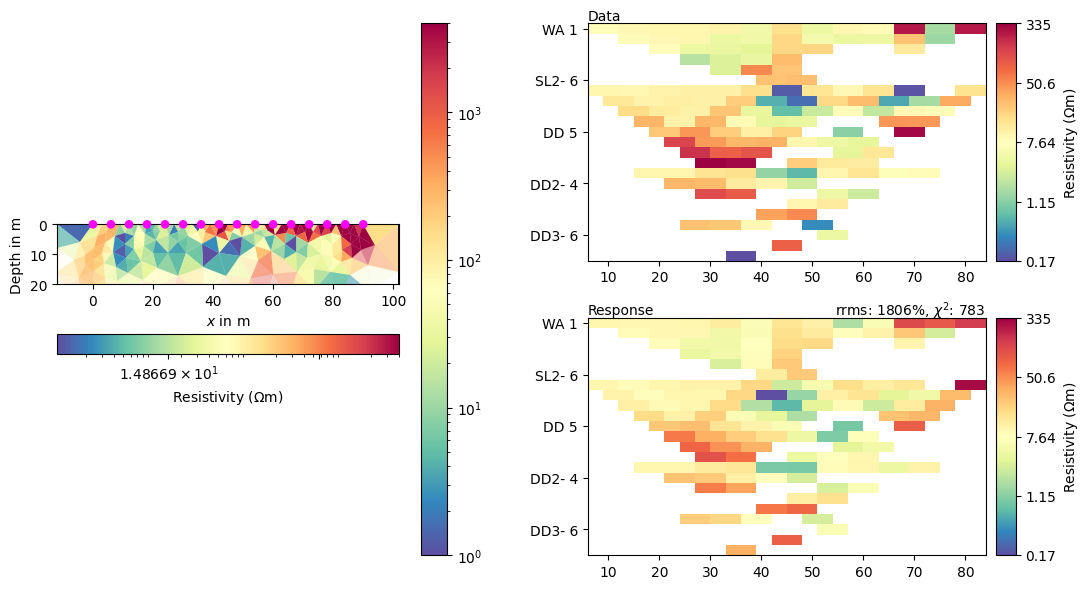

In [74]:
lamb = 1  # Regularization parameter
y_ax_lim = (-20, 0) #ex: (-20, 0)
cbar_ax_lim = (1, 4000)  #ex: (1, 100)

# Initialize ERTManager and perform inversion
mgr = ert.ERTManager(pygimli_dataout)
unstructured_model = mgr.invert(lam=lamb, verbose=False)

# Check inversion quality
print(f"Inversion stopped with chi² = {mgr.inv.chi2():.3f}")

#  Visualize results

#ax,cb = pg.show(mgr.paraDomain, unstructured_model, label='Resistivity (Ohm·m)', cMap='Spectral_r',
#        logScale=True)

fig = mgr.showResultAndFit();

# Access first axis with the resistivity model image
ax = fig.axes[0]

if y_ax_lim is not None:
    ax.set_ylim(*y_ax_lim)
if cbar_ax_lim is not None:
    image = ax.collections[0]  # usually the result image
    image.set_clim(vmin=cbar_ax_lim[0],vmax=cbar_ax_lim[1])
    fig.colorbar(image, ax=ax)

fig.savefig("unstructured_model.png",dpi=300)

### Structured data: Simple Grid


#### Geometry for the inversion

In [36]:
x_min = np.min(electrodes) - 10  # Extend 10 units beyond min electrode
x_max = np.max(electrodes) + 10  # Extend 10 units beyond max electrode
x_points = 10

y_min = -20  # Depth of the model
y_max = 0    # Surface
y_points = 10

x_linspace = np.linspace(start=x_min, stop=x_max , num=33)
y_space = -pg.cat([0], pg.utils.grange(y_max+0.0001, y_min*-1, n=y_points))[::-1]

print(f"World bounds: x_min={x_min}, x_max={x_max}, y_min={y_min}, y_max={y_max}")
print()
print(f"x_linspace: {x_linspace}")
print(f"y_space: {y_space}")

World bounds: x_min=-10.0, x_max=100.0, y_min=-20, y_max=0

x_linspace: [-10.      -6.5625  -3.125    0.3125   3.75     7.1875  10.625   14.0625
  17.5     20.9375  24.375   27.8125  31.25    34.6875  38.125   41.5625
  45.      48.4375  51.875   55.3125  58.75    62.1875  65.625   69.0625
  72.5     75.9375  79.375   82.8125  86.25    89.6875  93.125   96.5625
 100.    ]

y_space: 11 [-20.0, -17.77778888888889, -15.555577777777778, -13.333366666666667, -11.111155555555555, -8.888944444444444, -6.666733333333333, -4.444522222222222, -2.2223111111111113, -0.0001, -0.0]


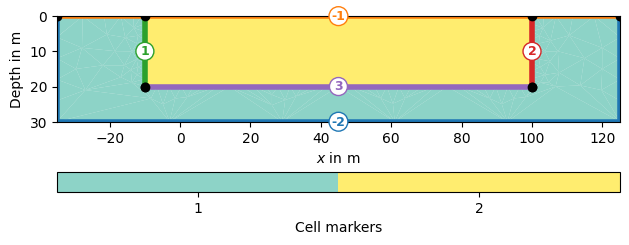

In [37]:
# custom grid
x_padding = 25
y_padding = 10

simple_inversionDomain = pg.createGrid(x=x_linspace,
                                y=y_space,
                                marker=2)
simple_grid = pg.meshtools.appendTriangleBoundary(simple_inversionDomain, marker=1,
                                           xbound=x_padding, ybound=y_padding)
pg.show(simple_grid, markers=True)
plt.savefig("structured_simple_mesh.png", dpi=300)
plt.show()

#### Inversion

INFO:pyGIMLi:Found 2 regions.
16/06/25 - 16:35:12 - pyGIMLi - INFO - Found 2 regions.
INFO:pyGIMLi:(ERTModelling) Region with smallest marker (1) set to background.
16/06/25 - 16:35:12 - pyGIMLi - INFO - (ERTModelling) Region with smallest marker (1) set to background.
INFO:pyGIMLi:Creating forward mesh from region infos.
16/06/25 - 16:35:12 - pyGIMLi - INFO - Creating forward mesh from region infos.
INFO:pyGIMLi:Creating refined mesh (H2) to solve forward task.
16/06/25 - 16:35:12 - pyGIMLi - INFO - Creating refined mesh (H2) to solve forward task.
INFO:pyGIMLi:Mesh for forward task: Mesh: Nodes: 1706 Cells: 2012 Boundaries: 1888
16/06/25 - 16:35:12 - pyGIMLi - INFO - Mesh for forward task: Mesh: Nodes: 1706 Cells: 2012 Boundaries: 1888
INFO:pyGIMLi:Use median(data values)=10.1643
16/06/25 - 16:35:12 - pyGIMLi - INFO - Use median(data values)=10.1643


Inversion stopped with chi² = 702.961


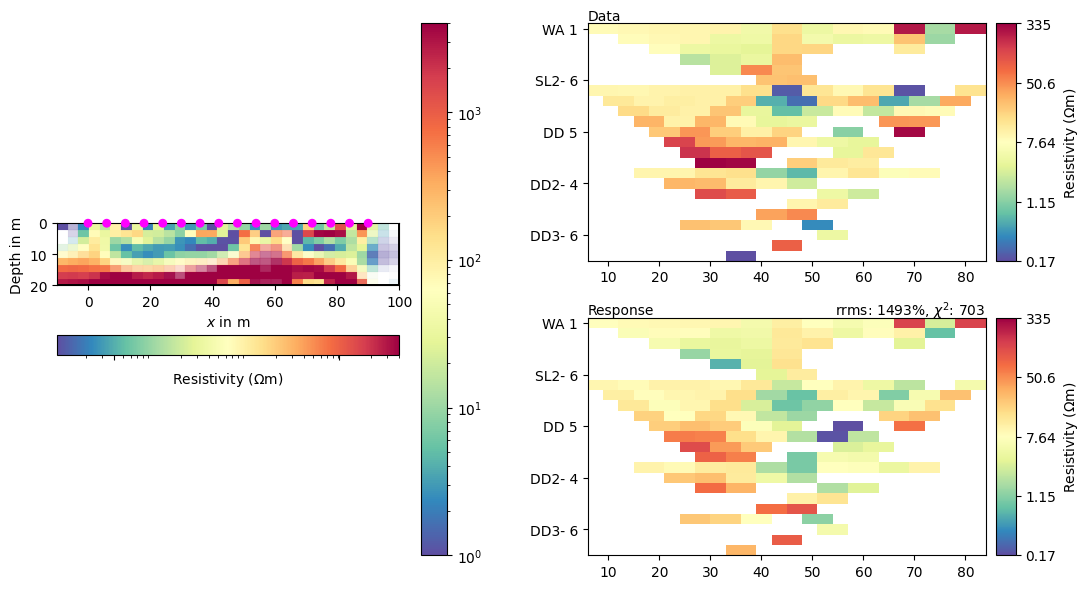

In [73]:
lamb = 1  # Regularization parameter
y_ax_lim = (-20, 0) #ex: (-20, 0)
cbar_ax_lim = (1, 4000)  #ex: (1, 100)

simple_mgr = ert.ERTManager(pygimli_dataout)

structured_simple_model = simple_mgr.invert(mesh=simple_grid, lam=lamb, verbose=False)

print(f"Inversion stopped with chi² = {simple_mgr.inv.chi2():.3f}")
fig = simple_mgr.showResultAndFit();

# Access first axis with the resistivity model image
ax = fig.axes[0]

if y_ax_lim is not None:
    ax.set_ylim(*y_ax_lim)
if cbar_ax_lim is not None:
    image = ax.collections[0]  # usually the result image
    image.set_clim(vmin=cbar_ax_lim[0],vmax=cbar_ax_lim[1])
    fig.colorbar(image, ax=ax)

fig.savefig("structured_simple_model.png",dpi=300)

### Structured data: Robust Grid

#### Geometry for the inversion

In [69]:
x_min = np.min(electrodes)
x_max = np.max(electrodes)
x_points = 40

y_min = -20  # Depth of the model
y_max = 0    # Surface
y_points = 30

x_linspace = np.linspace(start=x_min, stop=x_max , num=33)
y_space = -pg.cat([0], pg.utils.grange(y_max+0.0001, y_min*-1, n=y_points))[::-1]

print(f"World bounds: x_min={x_min}, x_max={x_max}, y_min={y_min}, y_max={y_max}")
print()
print(f"x_linspace: {x_linspace}")
print(f"y_space: {y_space}")

World bounds: x_min=0.0, x_max=90.0, y_min=-20, y_max=0

x_linspace: [ 0.      2.8125  5.625   8.4375 11.25   14.0625 16.875  19.6875 22.5
 25.3125 28.125  30.9375 33.75   36.5625 39.375  42.1875 45.     47.8125
 50.625  53.4375 56.25   59.0625 61.875  64.6875 67.5    70.3125 73.125
 75.9375 78.75   81.5625 84.375  87.1875 90.    ]

y_space: 31 [-20.0, -19.31034827586207, -18.620696551724137, -17.93104482758621, -17.241393103448278, -16.551741379310347, -15.862089655172415, -15.172437931034484, -14.482786206896552, -13.79313448275862, -13.10348275862069, -12.41383103448276, -11.724179310344828, -11.034527586206897, -10.344875862068966, -9.655224137931034, -8.965572413793105, -8.275920689655173, -7.586268965517242, -6.89661724137931, -6.20696551724138, -5.517313793103448, -4.827662068965517, -4.1380103448275865, -3.4483586206896555, -2.7587068965517245, -2.0690551724137936, -1.3794034482758621, -0.6897517241379311, -0.0001, -0.0]


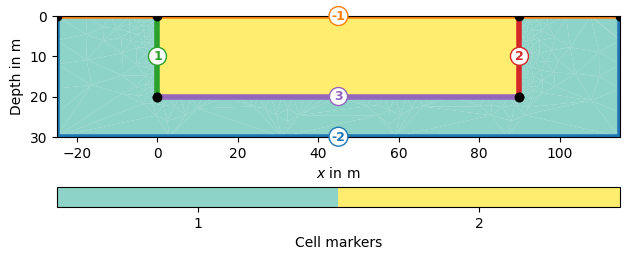

In [70]:
# custom grid
x_padding = 25
y_padding = 10

robust_inversionDomain = pg.createGrid(x=x_linspace,
                                y=y_space,
                                marker=2)
robust_grid = pg.meshtools.appendTriangleBoundary(robust_inversionDomain, marker=1,
                                           xbound=x_padding, ybound=y_padding)
pg.show(robust_grid, markers=True)
plt.savefig("structured_robust_mesh.png", dpi=300)

#### Inversion

INFO:pyGIMLi:Found 2 regions.
16/06/25 - 16:31:35 - pyGIMLi - INFO - Found 2 regions.
INFO:pyGIMLi:(ERTModelling) Region with smallest marker (1) set to background.
16/06/25 - 16:31:35 - pyGIMLi - INFO - (ERTModelling) Region with smallest marker (1) set to background.
INFO:pyGIMLi:Creating forward mesh from region infos.
16/06/25 - 16:31:35 - pyGIMLi - INFO - Creating forward mesh from region infos.
INFO:pyGIMLi:Creating refined mesh (H2) to solve forward task.
16/06/25 - 16:31:35 - pyGIMLi - INFO - Creating refined mesh (H2) to solve forward task.
INFO:pyGIMLi:Mesh for forward task: Mesh: Nodes: 4954 Cells: 5948 Boundaries: 5480
16/06/25 - 16:31:35 - pyGIMLi - INFO - Mesh for forward task: Mesh: Nodes: 4954 Cells: 5948 Boundaries: 5480
INFO:pyGIMLi:Use median(data values)=10.1643
16/06/25 - 16:31:36 - pyGIMLi - INFO - Use median(data values)=10.1643


Inversion stopped with chi² = 434.916


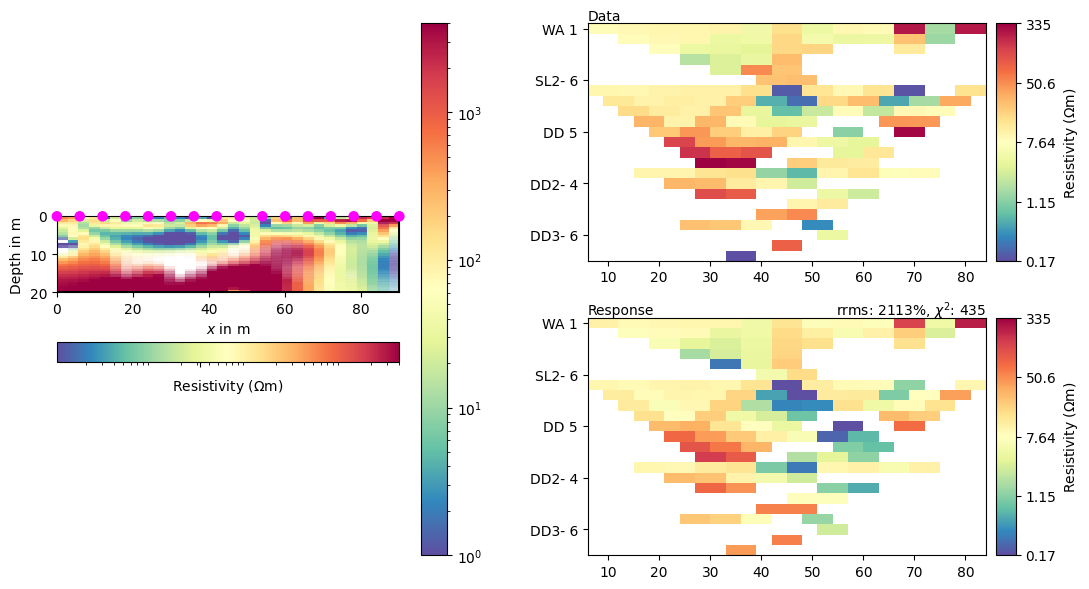

In [72]:
lamb = 1  # Regularization parameter
y_ax_lim = (-20, 0) #ex: (-20, 0)
cbar_ax_lim = (1, 4000)  #ex: (1, 100)

robust_mgr = ert.ERTManager(pygimli_dataout)

structured_robust_model = robust_mgr.invert(mesh=robust_grid, lam=lamb, verbose=False)

print(f"Inversion stopped with chi² = {robust_mgr.inv.chi2():.3f}")
fig = robust_mgr.showResultAndFit();

# Access first axis with the resistivity model image
ax = fig.axes[0]

if y_ax_lim is not None:
    ax.set_ylim(*y_ax_lim)
if cbar_ax_lim is not None:
    image = ax.collections[0]  # usually the result image
    image.set_clim(vmin=cbar_ax_lim[0],vmax=cbar_ax_lim[1])
    fig.colorbar(image, ax=ax)

fig.savefig("structured_robust_model.png",dpi=300)

**Well Done!** 🙂 🎉

You can find more material in the pygimli library: https://www.pygimli.org/documentation.html

Let us know any questions you have.

emmanuel.castillotaborda@utallas.edu & nadine.igonin@utdallas.edu